In [1]:
import datetime
import os
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn import functional as F

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
from d2l import torch as d2l
from tqdm import tqdm
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 自动检测设备

In [4]:
import torch
import torch.fft
import torch.nn.functional as F
import numpy as np
from torch import nn

class Conv2dGNGELU(nn.Sequential):
    def __init__(self, in_channel, out_channel, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv2d(in_channel, out_channel, kernel_size, stride, padding, groups=groups, bias=False),
            nn.GroupNorm(4, out_channel),
            nn.GELU()
        )
        
class Conv1dGNGELU(nn.Sequential):
    def __init__(self, in_channel, out_channel, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super().__init__(
            nn.Conv1d(in_channel, out_channel, kernel_size, stride, padding, groups=groups, bias=False),
            nn.GroupNorm(4, out_channel),
            nn.GELU()
        )
        
class DepthWiseConv2d(nn.Module):
    def __init__(self, dim_in, dim_out, kernel_size=3, padding=1, stride=1, dilation=1, norm_type='gn', gn_num=4):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(dim_in, dim_in, kernel_size=kernel_size, padding=padding, 
                    stride=stride, dilation=dilation, groups=dim_in),
            nn.BatchNorm2d(dim_in)  # 增强归一化
        )
        self.conv1 = nn.Conv2d(dim_in, dim_in, kernel_size=kernel_size, padding=padding, 
                      stride=stride, dilation=dilation, groups=dim_in)
        if norm_type == 'bn': self.norm_layer = nn.BatchNorm2d(dim_in)
        elif norm_type == 'in': self.norm_layer = nn.InstanceNorm2d(dim_in)
        elif norm_type == 'gn': self.norm_layer = nn.GroupNorm(gn_num, dim_in)
        else: raise('Error norm_type')
        self.conv2 = nn.Conv2d(dim_in, dim_out, kernel_size=1)

    def forward(self, x):
        return self.conv2(self.norm_layer(self.conv1(x)))

class InvertedDepthWiseConv2d(nn.Module):
    def __init__(self, in_channel, out_channel, kernel_size=3, stride=1, expand_ratio=2):
        super().__init__()
        hidden_channel = in_channel * expand_ratio
        self.use_shortcut = stride == 1 and in_channel == out_channel

        layers = []
        # 1x1 pointwise conv
        layers.append(Conv2dGNGELU(in_channel, hidden_channel, kernel_size=1))
        layers.extend([
            # 3x3 depthwise conv
            Conv2dGNGELU(hidden_channel, hidden_channel, kernel_size=kernel_size, stride=stride, groups=hidden_channel),
            # 1x1 pointwise conv(linear)
            nn.Conv2d(hidden_channel, out_channel, kernel_size=1, bias=False),
            nn.GroupNorm(4, out_channel),
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_shortcut:
            return x + self.conv(x)
        else:
            return self.conv(x)
        
        
class InvertedDepthWiseConv1d(nn.Module):
    def __init__(self, in_channel, out_channel, kernel_size=3, stride=1, expand_ratio=2):
        super().__init__()
        hidden_channel = in_channel * expand_ratio
        self.use_shortcut = stride == 1 and in_channel == out_channel

        layers = []
        # 1x1 pointwise conv
        layers.append(Conv1dGNGELU(in_channel, hidden_channel, kernel_size=1))
        layers.extend([
            # 3x3 depthwise conv
            Conv1dGNGELU(hidden_channel, hidden_channel, kernel_size=kernel_size, stride=stride, groups=hidden_channel),
            # 1x1 pointwise conv(linear)
            nn.Conv1d(hidden_channel, out_channel, kernel_size=1, bias=False),
            nn.GroupNorm(4, out_channel),
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_shortcut:
            return x + self.conv(x)
        else:
            return self.conv(x)


class MEW(nn.Module):
    def __init__(self, dim, bias=False, a=16, b=16, c_h=16, c_w=16):
        super().__init__()
        
        self.register_buffer("dim", torch.as_tensor(dim))
        self.register_buffer("a", torch.as_tensor(a))
        self.register_buffer("b", torch.as_tensor(b))
        self.register_buffer("c_h", torch.as_tensor(c_h))
        self.register_buffer("c_w", torch.as_tensor(c_w))
        
        self.a_weight = nn.Parameter(torch.Tensor(2, 1, dim // 4, a))
        nn.init.ones_(self.a_weight)
        self.b_weight = nn.Parameter(torch.Tensor(2, 1, dim // 4, b))
        nn.init.ones_(self.b_weight)
        self.c_weight = nn.Parameter(torch.Tensor(2, dim // 4, c_h, c_w))
        nn.init.ones_(self.c_weight)
        self.dw_conv = InvertedDepthWiseConv2d(dim // 4, dim // 4)
        
        self.wg_a = nn.Sequential(
            InvertedDepthWiseConv1d(dim // 4, 2 * dim // 4),
            InvertedDepthWiseConv1d(2 * dim // 4, 2 * dim // 4),
            InvertedDepthWiseConv1d(2 * dim // 4, dim // 4),
        )
        
        self.wg_b = nn.Sequential(
            InvertedDepthWiseConv1d(dim // 4, 2 * dim // 4),
            InvertedDepthWiseConv1d(2 * dim // 4, 2 * dim // 4),
            InvertedDepthWiseConv1d(2 * dim // 4, dim // 4),
        )
        
        self.wg_c = nn.Sequential(
            InvertedDepthWiseConv2d(dim // 4, 2 * dim // 4),
            InvertedDepthWiseConv2d(2 * dim // 4, 2 * dim // 4),
            InvertedDepthWiseConv2d(2 * dim // 4, dim // 4),
        )
        
    def forward(self, x):
        x1, x2, x3, x4 = torch.chunk(x, 4, dim=1)
        B, c, a, b = x1.size()
        #----- a convlution -----#
        x1 = x1.permute(0, 2, 1, 3) # B, a, c, b
        x1 = torch.fft.rfft2(x1, dim=(2, 3), norm='ortho')
        a_weight = self.a_weight
        a_weight = self.wg_a(F.interpolate(a_weight, size=x1.shape[2:4], 
                                           mode='bilinear', align_corners=True
                            ).squeeze(1)).unsqueeze(1).permute(1, 2, 3, 0)
        a_weight = torch.view_as_complex(a_weight.contiguous())
        x1 = x1 * a_weight
        x1 = torch.fft.irfft2(x1, s=(c, b), dim=(2, 3), norm='ortho').permute(0, 2, 1, 3)
        
        #----- b convlution -----#
        x2 = x2.permute(0, 3, 1, 2) # B, b, c, a
        x2 = torch.fft.rfft2(x2, dim=(2, 3), norm='ortho')
        b_weight = self.b_weight
        b_weight = self.wg_b(F.interpolate(b_weight, size=x2.shape[2:4], 
                                           mode='bilinear', align_corners=True
                            ).squeeze(1)).unsqueeze(1).permute(1, 2, 3, 0)
        b_weight = torch.view_as_complex(b_weight.contiguous())
        x2 = x2 * b_weight
        x2 = torch.fft.irfft2(x2, s=(c, a), dim=(2, 3), norm='ortho').permute(0, 2, 3, 1)
        
        #----- c convlution -----#
        x3 = torch.fft.rfft2(x3, dim=(2, 3), norm='ortho')
        c_weight = self.c_weight
        c_weight = self.wg_c(F.interpolate(c_weight, size=x3.shape[2:4], 
                                           mode='bilinear', align_corners=True)).permute(1, 2, 3, 0)
        c_weight = torch.view_as_complex(c_weight.contiguous())
        x3 = x3 * c_weight
        x3 = torch.fft.irfft2(x3, s=(a, b), dim=(2, 3), norm='ortho')
        
        #----- dw convlution -----#
        x4 = self.dw_conv(x4)
        
        #----- concat -----#
        out = torch.cat([x1, x2, x3, x4], dim=1)
        return out
    
class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4):
        super().__init__()
        
        self.mlp = nn.Sequential(InvertedDepthWiseConv2d(dim, mlp_ratio * dim),
                                 InvertedDepthWiseConv2d(mlp_ratio * dim, dim),
                                 nn.GELU()
                                )
    
    def forward(self, x):
        return self.mlp(x)
    
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.GroupNorm(4, dim)
        self.fn = fn
    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)

class MEWB(nn.Module):
    def __init__(self, dim, depth, mlp_ratio=4, drop_rate=0.2):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, MEW(dim)),
                PreNorm(dim, MLP(dim, mlp_ratio)),
                nn.Dropout2d(drop_rate)  # 新增空间dropout[6,7](@ref)
            ]))
    
    def forward(self, x):
        for attn, ff, dropout in self.layers:  # 修改此处
            x = attn(x) + x
            x = dropout(ff(x)) + x  # 添加dropout
        return x

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=4):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(inplace=True),
            # 移除 BatchNorm1d 层
            nn.Linear(in_channels // reduction_ratio, in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)
    
class MEWUNet(nn.Module):
    def __init__(self, in_c=3, num_classes=2, dim=[32, 64, 128, 256, 512], depth=[1, 2, 2, 4], mlp_ratio=4):
        super().__init__()
        
        self.e0 = nn.Sequential(
            DepthWiseConv2d(in_c, dim[0], norm_type='bn'),
        )
        self.e1 = nn.Sequential(
            DepthWiseConv2d(dim[0], dim[1]),
            MEWB(dim[1], depth[0], mlp_ratio)
        )
        self.e2 = nn.Sequential(
            DepthWiseConv2d(dim[1], dim[2]),
            MEWB(dim[2], depth[1], mlp_ratio)
        )
        self.e3 = nn.Sequential(
            DepthWiseConv2d(dim[2], dim[3]),
            MEWB(dim[3], depth[2], mlp_ratio)
        )
        self.e4= nn.Sequential(
            DepthWiseConv2d(dim[3], dim[4]),
            MEWB(dim[4], depth[3], mlp_ratio)
        )
        self.d4 = nn.Sequential(
            MEWB(dim[4], depth[3], mlp_ratio),
            DepthWiseConv2d(dim[4], dim[3])
        )

        # Channel Attention
        self.channel_att = ChannelAttention(dim[4])
        # Classification Head
        # self.classification=nn.Sequential(
        #     nn.Dropout(0.5),
        #     nn.Flatten(), 
        #     nn.Linear(25088, 1024),
        #     nn.Sigmoid(),
        #     nn.Linear(1024, 256),
        #     nn.ReLU(inplace=True),
        #     nn.Linear(256, num_classes)
        # )
        # 修改分类头增强正则化
        self.classification = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 新增全局池化代替Flatten
            nn.Dropout(0.5),  # 提升dropout比率
            nn.Flatten(),
            nn.Linear(dim[4], dim[4]//2),  # 减少全连接层维度
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dim[4]//2, num_classes)
        )
        
    def forward(self, x):
        if x.size()[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        #------encoder------#
        x0 = F.max_pool2d(self.e0(x), 2, 2) # b, c0, h/2, w/2
        x1 = F.max_pool2d(self.e1(x0), 2, 2) # b, c1, h/4, w/4
        x2 = F.max_pool2d(self.e2(x1), 2, 2) # b, c2, h/8, w/8
        x3 = F.max_pool2d(self.e3(x2), 2, 2) # b, c3, h/16, w/16
        x4 = F.max_pool2d(self.e4(x3), 2, 2) # b, c4, h/32, w/32
        x5 = self.channel_att(x4)
        
        # Classification Head
        output=self.classification(x5)
        return output


In [5]:
input_channels = 3
num_classes = 2
img_size = (224, 224)  # Kaggle数据集尺寸
batch_size = 16
dim=[16, 32, 64, 128, 256]
depth=[1, 1, 1, 2]
MEWUNet = MEWUNet(num_classes=num_classes,dim=dim,depth=depth).to(device)  # 模型送GPU
print(len(list(MEWUNet.parameters()))) 
# 正常应有20+参数层，若数量异常说明注册失败[3](@ref)

849


In [15]:
from torchsummary import summary
summary(MEWUNet, input_size=(3, 224, 224))  # 输入尺寸需与实际匹配

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 3, 224, 224]              30
       BatchNorm2d-2          [-1, 3, 224, 224]               6
            Conv2d-3         [-1, 16, 224, 224]              64
   DepthWiseConv2d-4         [-1, 16, 224, 224]               0
            Conv2d-5         [-1, 16, 112, 112]             160
         GroupNorm-6         [-1, 16, 112, 112]              32
            Conv2d-7         [-1, 32, 112, 112]             544
   DepthWiseConv2d-8         [-1, 32, 112, 112]               0
         GroupNorm-9         [-1, 32, 112, 112]              64
           Conv1d-10               [-1, 16, 57]             128
        GroupNorm-11               [-1, 16, 57]              32
             GELU-12               [-1, 16, 57]               0
           Conv1d-13               [-1, 16, 57]              48
        GroupNorm-14               [-1,

In [17]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [19]:
def load_checkpoint(model, optimizer, scheduler=None, path='last_model.pth'):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler and checkpoint['scheduler_state_dict']:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1  # 从下一epoch开始
    print(f"Resuming from epoch {checkpoint['epoch']}")  
    return start_epoch

In [21]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    
    print('training on', device)
    net.to(device)
    #optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=0.05)  # L2正则化
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    
    #根据保存的参数继续训练
    start_epoch=0
    start_epoch = load_checkpoint(net, optimizer)
    
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    test_acc_best=0
    corresponding_train_acc=0
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            # 更新学习率
            scheduler.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        if test_acc > test_acc_best:
            test_acc_best=test_acc
            corresponding_train_acc=train_acc
            #保存test acc最好的模型参数
            checkpoint = {
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'test_acc_best': test_acc_best,
                'epoch': epoch+start_epoch
            }
            torch.save(checkpoint, 'best_model.pth')
        #保存最后一次训练参数模型
        checkpoint = {
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch+start_epoch,
            'last_test_acc': test_acc
        }
        torch.save(checkpoint, 'last_model.pth')
            
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}\n' 
          f'best test acc {test_acc_best:.3f},corresponding train acc {corresponding_train_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

In [23]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# 数据预处理配置
transform = transforms.Compose([
    transforms.Resize((224, 224)),       # 统一尺寸
    transforms.RandomHorizontalFlip(p=0.5),  # 以50%的概率水平翻转图像
    transforms.ColorJitter(
        brightness=0.2,  # 亮度调整因子（范围：[1-0.2, 1+0.2]）
        contrast=0.2,    # 对比度调整因子（范围：[1-0.2, 1+0.2]）
        saturation=0.2,  # 饱和度调整因子（范围：[1-0.2, 1+0.2]）
        hue=0.1          # 色调偏移范围（范围：[-0.1, 0.1]）
    ),
    transforms.ToTensor(),              # 转为Tensor
])

# 在数据加载部分添加更强的数据增强（以图像分类为例）
# transform = transforms.Compose([
#     transforms.RandomResizedCrop(224),  # 随机裁剪缩放
#     transforms.RandomHorizontalFlip(p=0.5),  # 以50%的概率水平翻转图像
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2,hue=0.1),  # 颜色抖动
#     transforms.RandomRotation(15),  # 随机旋转
#     transforms.RandomAffine(degrees=0, shear=0.2),  # 仿射变换
#     transforms.ToTensor() # 转为Tensor
# ])

# 加载完整数据集（假设目录结构为`./data/NC`和`./data/SLE`）
full_dataset = datasets.ImageFolder(
    root='E:/LazySheep/Desktop/total/T_test',
    transform=transform
)

# 划分训练集和测试集（8:2比例）
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # 固定随机种子保证可复现
)

# 创建DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=True  # GPU训练时加速数据加载
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=4
)

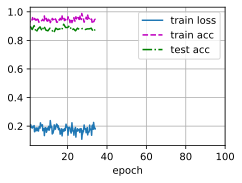

In [ ]:
lr = 3e-5
num_epoch =  100
# 可以选用不同的网络
train_ch6(MEWUNet, train_loader, test_loader, num_epoch, lr, d2l.try_gpu())

In [29]:
# 加载参数文件
checkpoint = torch.load('best_model.pth', map_location=torch.device('cuda'))  # 指定设备

# 严格模式加载（推荐默认）
MEWUNet.load_state_dict(checkpoint['model_state_dict'], strict=True)  
MEWUNet.eval()  # 关闭Dropout/BatchNorm的训练行为

MEWUNet(
  (e0): Sequential(
    (0): DepthWiseConv2d(
      (conv1): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3)
      (norm_layer): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (e1): Sequential(
    (0): DepthWiseConv2d(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16)
      (norm_layer): GroupNorm(4, 16, eps=1e-05, affine=True)
      (conv2): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): MEWB(
      (layers): ModuleList(
        (0): ModuleList(
          (0): PreNorm(
            (norm): GroupNorm(4, 32, eps=1e-05, affine=True)
            (fn): MEW(
              (dw_conv): InvertedDepthWiseConv2d(
                (conv): Sequential(
                  (0): Conv2dGNGELU(
                    (0): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
                    (1): Gro

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, 
    roc_auc_score, f1_score, matthews_corrcoef, log_loss,
    confusion_matrix, classification_report
)

def evaluate_medical_model(model, test_loader, device, num_classes=2, alpha=0.05, n_bootstraps=1000):
    """
    增强版医疗模型综合评估函数
    包含ROC/PR曲线可视化、置信区间和p值计算
    特别强化敏感性和特异性指标，适用于SLE病例分类
    
    参数:
        model: 训练好的PyTorch模型
        test_loader: 测试数据加载器
        device: 计算设备 (cuda/cpu)
        num_classes: 分类数 (默认2)
        alpha: 置信水平 (默认0.05)
        n_bootstraps: Bootstrap抽样次数 (默认1000)
        
    返回:
        包含所有评估指标的字典
    """
    model.eval()
    metrics = {
        'total_correct': 0,
        'total_samples': 0,
        'pos_correct': 0,
        'neg_correct': 0,
        'pos_samples': 0,
        'neg_samples': 0,
        'all_labels': [],
        'all_probs': [],
        'all_preds': []
    }

    # 数据收集阶段
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            # 统计基础指标
            metrics['total_correct'] += (preds == labels).sum().item()
            metrics['total_samples'] += labels.size(0)
            
            # 正负样本统计
            pos_mask = (labels == 1)
            neg_mask = (labels == 0)
            metrics['pos_correct'] += (preds[pos_mask] == labels[pos_mask]).sum().item()
            metrics['neg_correct'] += (preds[neg_mask] == labels[neg_mask]).sum().item()
            metrics['pos_samples'] += pos_mask.sum().item()
            metrics['neg_samples'] += neg_mask.sum().item()
            
            # 收集评估所需数据
            metrics['all_labels'].extend(labels.cpu().numpy())
            metrics['all_probs'].extend(probs[:, 1].cpu().numpy())  # 取正类概率
            metrics['all_preds'].extend(preds.cpu().numpy())

    # 转换为numpy数组
    y_true = np.array(metrics['all_labels'])
    y_pred = np.array(metrics['all_preds'])
    y_probs = np.array(metrics['all_probs'])
    
    # 计算混淆矩阵元素
    TP = metrics['pos_correct']
    TN = metrics['neg_correct']
    FP = metrics['neg_samples'] - TN
    FN = metrics['pos_samples'] - TP
    
    # 构建混淆矩阵
    cm = np.array([[TN, FP], [FN, TP]])
    
    # ================== 计算核心医疗指标 ==================
    final_metrics = {
        'accuracy': (TP + TN) / (TP + TN + FP + FN),
        'sensitivity': TP / (TP + FN) if (TP + FN) > 0 else 0,  # 召回率/敏感性
        'specificity': TN / (TN + FP) if (TN + FP) > 0 else 0,  # 特异性
        'precision': TP / (TP + FP) if (TP + FP) > 0 else 0,
        'f1_score': f1_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_probs),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'log_loss': log_loss(y_true, y_probs),
        'fpr': FP / (FP + TN) if (FP + TN) > 0 else 0,  # 假阳性率
        'fnr': FN / (FN + TP) if (FN + TP) > 0 else 0,  # 假阴性率
        'confusion_matrix': cm,
        'confusion_matrix_elements': {'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN}
    }
    
    # ================== 统计显著性分析 ==================
    # 1. 计算准确率的p值（二项检验）
    baseline_acc = max(metrics['pos_samples'], metrics['neg_samples']) / metrics['total_samples']
    
    # 使用binomtest替代已弃用的binom_test
    binomial_test = stats.binomtest(
        k=metrics['total_correct'],
        n=metrics['total_samples'],
        p=baseline_acc,
        alternative='greater'
    )
    p_value_acc = binomial_test.pvalue
    
    # 2. Bootstrap计算置信区间
    def bootstrap_metric(metric_func, labels, probs, n_bootstraps=1000):
        values = []
        for _ in range(n_bootstraps):
            # 重抽样
            idx = np.random.choice(len(labels), len(labels), replace=True)
            resampled_labels = labels[idx]
            resampled_probs = probs[idx]
            
            # 计算指标
            if metric_func == roc_auc_score:
                if len(np.unique(resampled_labels)) < 2:
                    values.append(0.5)
                else:
                    values.append(metric_func(resampled_labels, resampled_probs))
            else:
                preds = (resampled_probs > 0.5).astype(int)
                values.append(metric_func(resampled_labels, preds))
        
        # 计算置信区间
        lower = np.percentile(values, 100 * alpha/2)
        upper = np.percentile(values, 100 * (1 - alpha/2))
        return (lower, upper)
    
    # 3. 关键指标置信区间计算
    ci_auc = bootstrap_metric(roc_auc_score, y_true, y_probs, n_bootstraps)
    ci_f1 = bootstrap_metric(f1_score, y_true, y_probs, n_bootstraps)
    ci_sensitivity = bootstrap_metric(
        lambda y_true, y_pred: np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1),
        y_true, (y_probs > 0.5).astype(int), n_bootstraps
    )
    
    # 添加统计指标
    final_metrics.update({
        'p_value': {
            'acc_vs_baseline': p_value_acc,
        },
        'confidence_interval': {
            'auc': ci_auc,
            'f1': ci_f1,
            'sensitivity': ci_sensitivity,
        },
        'statistical_significance': {
            'baseline_accuracy': baseline_acc,
            'alpha': alpha,
            'bootstrap_rounds': n_bootstraps
        }
    })
    
    # ================== 可视化部分 ==================
    plt.figure(figsize=(15, 5))
    
    # 1. ROC曲线
    plt.subplot(131)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")

    # 2. PR曲线（医疗重点）
    plt.subplot(132)
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="upper right")

    # 3. 混淆矩阵热力图
    plt.subplot(133)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['NC', 'SLE'], 
                yticklabels=['NC', 'SLE'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.savefig('medical_model_evaluation.png', dpi=300)
    plt.show()

    # 添加分类报告
    print("\n" + "="*60)
    print(classification_report(y_true, y_pred, target_names=['NC', 'SLE']))
    print("="*60 + "\n")
    
    return final_metrics

In [35]:
# 加载参数文件
checkpoint = torch.load('best_model.pth', map_location=torch.device('cuda'))  # 指定设备

# 严格模式加载（推荐默认）
MEWUNet.load_state_dict(checkpoint['model_state_dict'], strict=True)  
MEWUNet.eval()  # 关闭Dropout/BatchNorm的训练行为

MEWUNet(
  (e0): Sequential(
    (0): DepthWiseConv2d(
      (conv1): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=3)
      (norm_layer): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (e1): Sequential(
    (0): DepthWiseConv2d(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16)
      (norm_layer): GroupNorm(4, 16, eps=1e-05, affine=True)
      (conv2): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): MEWB(
      (layers): ModuleList(
        (0): ModuleList(
          (0): PreNorm(
            (norm): GroupNorm(4, 32, eps=1e-05, affine=True)
            (fn): MEW(
              (dw_conv): InvertedDepthWiseConv2d(
                (conv): Sequential(
                  (0): Conv2dGNGELU(
                    (0): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
                    (1): Gro

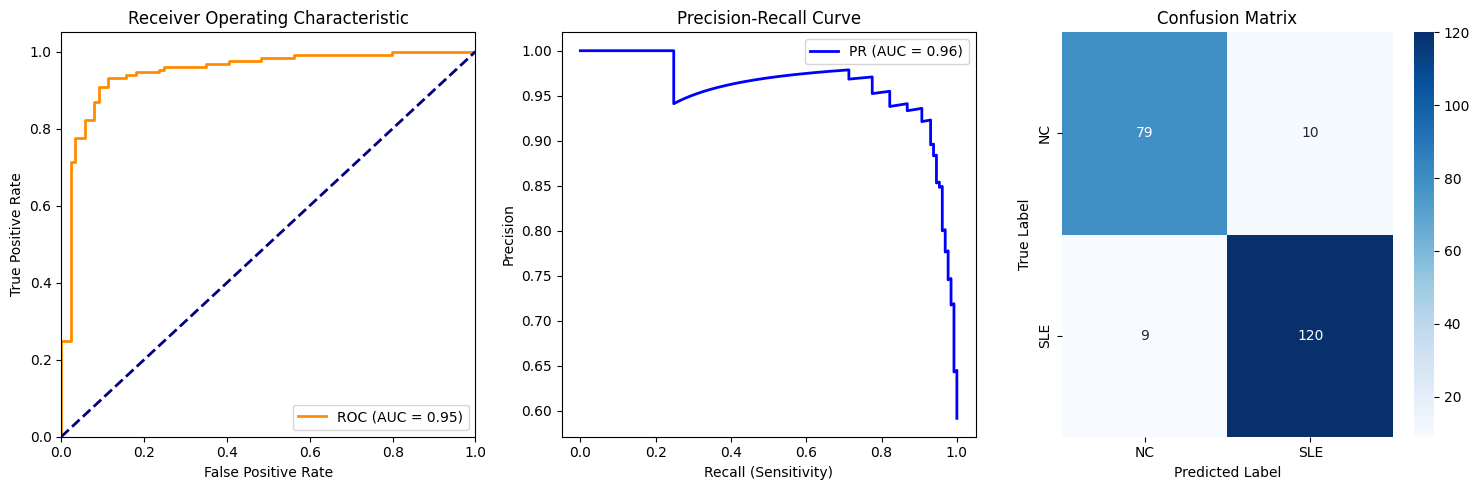


              precision    recall  f1-score   support

          NC       0.90      0.89      0.89        89
         SLE       0.92      0.93      0.93       129

    accuracy                           0.91       218
   macro avg       0.91      0.91      0.91       218
weighted avg       0.91      0.91      0.91       218


敏感性: 0.9302 [95%CI: 0.881-0.970]
特异性: 0.8876
F1分数: 0.9266
精确率：0.9231 | 召回率：0.8876
MCC：0.8193 | 对数损失：0.2846
AUC-ROC: 0.9486 [95%CI: 0.911-0.978]
模型优于基准的统计显著性: p=0.0000


In [39]:
# 初始化设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 执行评估
metrics = evaluate_medical_model(
    MEWUNet, 
    test_loader, 
    device,
    n_bootstraps=200  # 推荐小样本使用更多抽样
)

# 输出关键医疗指标
print(f"敏感性: {metrics['sensitivity']:.4f} [95%CI: {metrics['confidence_interval']['sensitivity'][0]:.3f}-{metrics['confidence_interval']['sensitivity'][1]:.3f}]")
print(f"特异性: {metrics['specificity']:.4f}")
print(f"F1分数: {metrics['f1_score']:.4f}")
print(f"精确率：{metrics['precision']:.4f} | 召回率：{metrics['specificity']:.4f}")
print(f"MCC：{metrics['mcc']:.4f} | 对数损失：{metrics['log_loss']:.4f}") #MCC越接近1越好
print(f"AUC-ROC: {metrics['auc_roc']:.4f} [95%CI: {metrics['confidence_interval']['auc'][0]:.3f}-{metrics['confidence_interval']['auc'][1]:.3f}]")
print(f"模型优于基准的统计显著性: p={metrics['p_value']['acc_vs_baseline']:.4f}")